In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10, 6)
sns.set(style="whitegrid")

In [2]:
events_obs_df = pd.read_csv(
    "../data/processed/ethiopia_new.csv",
    parse_dates=["observation_date", "period_start", "period_end", "collection_date"]
)

impact_links_df = pd.read_csv(
    "../data/processed/impact_new.csv",
    parse_dates=["observation_date", "collection_date"]
)


C:\Users\ruthg\AppData\Local\Temp\ipykernel_28024\1202287608.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  events_obs_df = pd.read_csv(


In [3]:
events_obs_df["record_type"] = (
    events_obs_df["record_type"].astype(str).str.strip().str.lower()
)
impact_links_df["record_type"] = (
    impact_links_df["record_type"].astype(str).str.strip().str.lower()
)

In [4]:
events_df = events_obs_df[events_obs_df["record_type"] == "event"].copy()
observations_df = events_obs_df[events_obs_df["record_type"] == "observation"].copy()

len(events_df), len(observations_df), len(impact_links_df)

(13, 36, 18)

In [5]:
event_impact_df = impact_links_df.merge(
    events_df[[
        "record_id",
        "indicator",          
        "category",
        "observation_date"
    ]],
    left_on="parent_id",
    right_on="record_id",
    how="left",
    suffixes=("", "_event")
)

event_impact_df.rename(columns={
    "indicator": "event_name",
    "observation_date": "event_date"
}, inplace=True)

event_impact_df[["parent_id", "event_name", "event_date"]].head()


,parent_id,event_name,event_date
0,EVT_0001,Telebirr effect on Account Ownership,2021-05-17
1,EVT_0001,Telebirr effect on Telebirr Users,2021-05-17
2,EVT_0001,Telebirr effect on P2P Transactions,2021-05-17
3,EVT_0002,Safaricom effect on 4G Coverage,2022-08-01
4,EVT_0002,Safaricom effect on Data Affordability,2022-08-01


In [6]:
event_impact_df["event_name"] = event_impact_df["event_name"].fillna("Unknown Event")
event_impact_df["related_indicator"] = event_impact_df["related_indicator"].fillna("Unknown Indicator")


event_impact_df["impact_value"] = (
    event_impact_df["impact_estimate"]
    .fillna(event_impact_df["impact_magnitude"])
    .fillna(0)
)

event_impact_df["direction"] = event_impact_df["impact_direction"].map({
    "increase": 1,
    "decrease": -1
}).fillna(0)

event_impact_df["signed_impact"] = (
    event_impact_df["direction"] * event_impact_df["impact_value"]
)


In [7]:
event_impact_df["impact_value"] = pd.to_numeric(
    event_impact_df["impact_value"],
    errors="coerce"
)

event_impact_df["signed_impact"] = pd.to_numeric(
    event_impact_df["signed_impact"],
    errors="coerce"
).fillna(0)
event_impact_df["signed_impact"].dtype

dtype('float64')

In [8]:
association_matrix = event_impact_df.pivot_table(
    index="event_name",
    columns="related_indicator",
    values="signed_impact",
    aggfunc="mean",
    fill_value=0
)


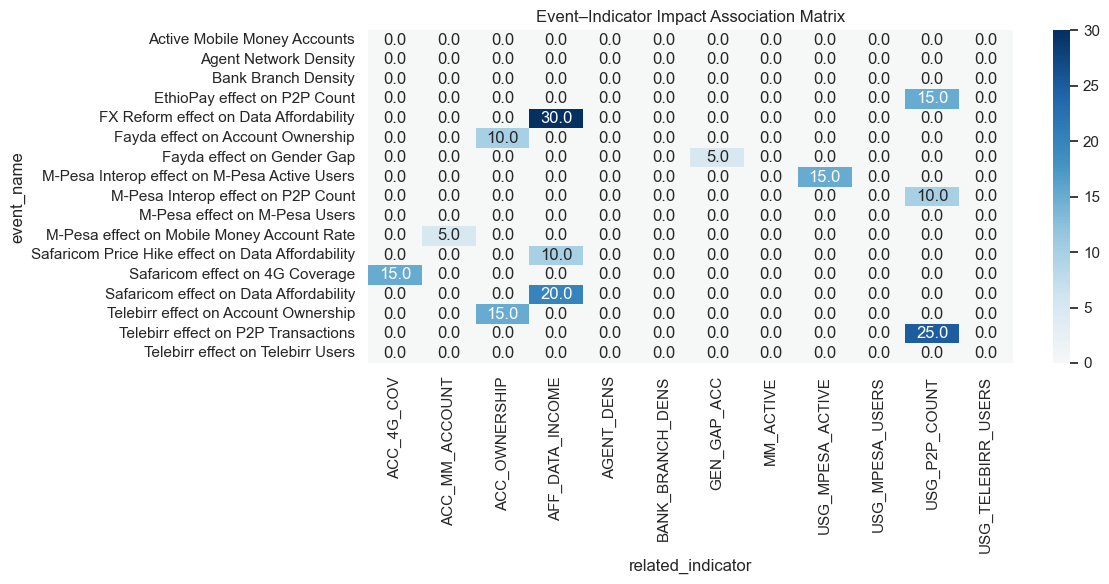

In [9]:
plt.figure(figsize=(12, 6))
sns.heatmap(
    association_matrix,
    cmap="RdBu",
    center=0,
    annot=True,
    fmt=".1f"
)
plt.title("Event–Indicator Impact Association Matrix")
plt.tight_layout()
plt.show()


In [ ]:
impact_rows = []
timeline = pd.date_range(start="2014-01-01", end="2026-12-01", freq="MS")

for _, row in event_impact_df.iterrows():
    for t in timeline:
        months_since = (
            (t.year - row["event_date"].year) * 12 +
            (t.month - row["event_date"].month) -
            row["lag_months"]
        )

        shape = "ramp" if row["evidence_basis"] in ["literature","comparable"] else "step"

        if months_since < 0:
            impact = 0
        else:
            if shape == "step":
                impact = row["signed_impact"]
                impact = row["signed_impact"] * min(months_since/24, 1)

        impact_rows.append({
            "date": t,
            "indicator_code": row["related_indicator"] if pd.notna(row["related_indicator"]) else "Unknown Indicator",
            "impact": impact
        })

indicator_impact_ts = pd.DataFrame(impact_rows)


In [12]:
indicator_impact_ts.head()

,date,indicator_code,impact
0,2014-01-01,ACC_OWNERSHIP,0.0
1,2014-02-01,ACC_OWNERSHIP,0.0
2,2014-03-01,ACC_OWNERSHIP,0.0
3,2014-04-01,ACC_OWNERSHIP,0.0
4,2014-05-01,ACC_OWNERSHIP,0.0


In [13]:
indicator_impact_ts = (
    indicator_impact_ts
    .groupby(["date", "indicator_code"])["impact"]
    .sum()
    .reset_index()
)

indicator_impact_ts.head()

,date,indicator_code,impact
0,2014-01-01,ACC_4G_COV,0.0
1,2014-01-01,ACC_MM_ACCOUNT,0.0
2,2014-01-01,ACC_OWNERSHIP,0.0
3,2014-01-01,AFF_DATA_INCOME,0.0
4,2014-01-01,AGENT_DENS,0.0


In [14]:
confidence_map = {
    "high": "High",
    "medium": "Medium",
    "low": "Low"
}

event_impact_df["confidence_label"] = (
    event_impact_df["confidence"]
    .astype(str)
    .str.lower()
    .map(confidence_map)
    .fillna("Low")
)


In [16]:
association_matrix.to_csv("../data/processed/event_indicator_matrix.csv")

indicator_impact_ts.to_csv("../data/processed/indicator_impact_timeseries.csv", index=False)

event_impact_df[[
    "event_name",
    "related_indicator",
    "signed_impact",
    "lag_months",
    "evidence_basis",
    "comparable_country",
    "confidence_label"
]].to_csv("../data/processed/impact_documentation.csv", index=False)

In [18]:
yearly_impact = indicator_impact_ts.groupby([indicator_impact_ts.date.dt.year, "indicator_code"])["impact"].sum().reset_index()

In [30]:
historical_data = observations_df[
    observations_df['indicator_code'].isin(['ACC_OWNERSHIP', 'USG_P2P_COUNT'])
][['observation_date', 'indicator_code', 'value_numeric']].copy()

historical_data['year'] = historical_data['observation_date'].dt.year
historical_data = historical_data.groupby(['year', 'indicator_code'])['value_numeric'].mean().reset_index()

historical_data.rename(columns={'value_numeric': 'value'}, inplace=True)

historical_data.tail()


,year,indicator_code,value
1,2017,ACC_OWNERSHIP,35.0
2,2021,ACC_OWNERSHIP,46.0
3,2024,ACC_OWNERSHIP,49.0
4,2024,USG_P2P_COUNT,49700000.0
5,2025,USG_P2P_COUNT,128300000.0


In [21]:
indicator_impact_ts['year'] = indicator_impact_ts['date'].dt.year

yearly_impact_values = (
    indicator_impact_ts.groupby(['year', 'indicator_code'])['impact']
    .sum()
    .reset_index()
)
yearly_impact_values.head()


,year,indicator_code,impact
0,2014,ACC_4G_COV,0.0
1,2014,ACC_MM_ACCOUNT,0.0
2,2014,ACC_OWNERSHIP,0.0
3,2014,AFF_DATA_INCOME,0.0
4,2014,AGENT_DENS,0.0


In [22]:
event_impact_df['confidence'] = event_impact_df['confidence'].astype(str).str.lower()

In [23]:
confidence_score_map = {
    "high": 0.0,
    "medium": 0.5,
    "low": 1.0,
    "nan": 0.5   
}

event_impact_df['confidence_score'] = (
    event_impact_df['confidence']
    .map(confidence_score_map)
    .fillna(0.5)
)


In [24]:
event_impact_df[['confidence','confidence_score']].drop_duplicates()

,confidence,confidence_score
0,medium,0.5
1,high,0.0
14,NaN,0.5


In [25]:
event_impact_df['event_uncertainty'] = (
    event_impact_df['signed_impact'].abs() * event_impact_df['confidence_score']
)

In [26]:
event_impact_df['year'] = event_impact_df['event_date'].dt.year

event_uncertainty = (
    event_impact_df
    .groupby(['year', 'related_indicator'])['event_uncertainty']
    .sum()
    .reset_index()
    .rename(columns={'related_indicator': 'indicator'})
)

In [27]:
yearly_impact_values = (
    event_impact_df
    .groupby(['year', 'related_indicator'])['signed_impact']
    .sum()
    .reset_index()
    .rename(columns={'related_indicator': 'indicator',
                     'signed_impact': 'impact'})
)
print(event_uncertainty.columns)
print(yearly_impact_values.columns)


Index(['year', 'indicator', 'event_uncertainty'], dtype='str')
Index(['year', 'indicator', 'impact'], dtype='str')


In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

forecast_years = np.array([2025, 2026, 2027]).reshape(-1, 1)
rows = []

for ind in ['ACC_OWNERSHIP', 'USG_P2P_COUNT']:
    hist = historical_data[historical_data['indicator_code'] == ind]

    X = hist['year'].values.reshape(-1, 1)
    y = hist['value'].values

    model = LinearRegression().fit(X, y)
    trend = model.predict(forecast_years)

    for i, yr in enumerate([2025, 2026, 2027]):
        rows.append({
            'year': yr,
            'indicator': ind,
            'base_with_events': trend[i],
            'optimistic': trend[i] * 1.10,
            'pessimistic': trend[i] * 0.90
        })

forecast_df = pd.DataFrame(rows)


,year,indicator,base_with_events,optimistic,pessimistic
0,2025,ACC_OWNERSHIP,5.424138e+01,5.966552e+01,4.881724e+01
1,2026,ACC_OWNERSHIP,5.694828e+01,6.264310e+01,5.125345e+01
2,2027,ACC_OWNERSHIP,5.965517e+01,6.562069e+01,5.368966e+01
3,2025,USG_P2P_COUNT,1.283000e+08,1.411300e+08,1.154700e+08
4,2026,USG_P2P_COUNT,2.069000e+08,2.275900e+08,1.862100e+08
5,2027,USG_P2P_COUNT,2.855000e+08,3.140500e+08,2.569500e+08


In [32]:
forecast_df.to_csv("forecast_results.csv", index=False)